
# Energy-based EDA for IEMOCAP Dataset

이 노트북은 IEMOCAP 데이터셋에 대한 Energy (RMS Amplitude) 단위 탐색적 데이터 분석(EDA)을 수행합니다.

## 분석 내용:
- 감정별 Energy 통계 (평균, 표준편차, 최소/최대값)
- 감정별 Energy 분포 시각화
- Energy 범위 및 변동성 분석
- Energy contour 시각화 (Waveform 대신 Energy Envelope 집중 분석)
- 감정별 비교 분석


In [9]:

# 필요한 라이브러리 임포트
import sys
import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
import librosa
import librosa.display
from datasets import load_dataset, Audio
import soundfile as sf
import io
import warnings
warnings.filterwarnings('ignore')

# 경로 설정 및 임포트
if os.path.abspath("..") not in sys.path:
    sys.path.append(os.path.abspath(".."))

try:
    from src.model import MultimodalEmotionModel
    from src.config import SAMPLE_RATE, MAX_AUDIO_LEN, MAX_TEXT_LEN, EMOTIONS, ID2EMOTION
except ImportError:
    # src 경로가 안 잡힐 경우를 대비해 현재 디렉토리 기준 추가
    sys.path.append(os.path.abspath("src"))
    from src.model import MultimodalEmotionModel
    from src.config import SAMPLE_RATE, MAX_AUDIO_LEN, MAX_TEXT_LEN, EMOTIONS, ID2EMOTION

# 시각화 스타일 설정
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (15, 8)
plt.rcParams['font.size'] = 12

print("라이브러리 로드 완료!")


라이브러리 로드 완료!


## 1. 데이터셋 로드

In [10]:

# 디바이스 설정
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Using device: {device}")

# 학습된 모델 로드
print("모델 로딩 중...")

# ⚠️ MPS 버그 해결: CPU에서 먼저 로드한 후 MPS로 이동
try:
    model = MultimodalEmotionModel(num_classes=4)
    checkpoint = torch.load('../models/best_model.pt', map_location='cpu')
    model.load_state_dict(checkpoint['model_state_dict'])
    print("✅ 모델 state_dict 로드 완료 (CPU)")

    model.to(device)
    model.eval()
    print(f"✅ 모델을 {device}로 이동 완료!")
    print(f"   Epoch {checkpoint.get('epoch', 'N/A')}, Acc: {checkpoint.get('val_acc', 'N/A')}")
except Exception as e:
    print(f"⚠️ 모델 로드 중 오류 발생 (무시하고 진행 가능): {e}")

# Tokenizer
from transformers import RobertaTokenizer
tokenizer = RobertaTokenizer.from_pretrained('roberta-base')

# 데이터셋 로드 - 오디오 디코딩 완전 우회
print("\n데이터셋 로딩 중...")
print("Loading IEMOCAP dataset (without audio decoding)...")
ds = load_dataset("AbstractTTS/IEMOCAP", split="train")

# ✅ 핵심: 오디오 디코딩 끄기 (torchcodec 회피)
ds = ds.cast_column("audio", Audio(decode=False))

# 메타데이터만 사용해서 필터링
target_emotions = ['angry', 'sad', 'happy', 'excited', 'neutral']
print("Filtering by emotion...")

filtered_indices = []
for idx, example in enumerate(tqdm(ds, desc="Filtering")):
    if example['major_emotion'] in target_emotions:
        filtered_indices.append(idx)

ds = ds.select(filtered_indices)
print(f"Filtered to {len(ds)} samples")

# 레이블 매핑
def map_label(example):
    emo = example['major_emotion']
    if emo == 'angry':
        label = EMOTIONS['ang']
    elif emo == 'sad':
        label = EMOTIONS['sad']
    elif emo in ['happy', 'excited']:
        label = EMOTIONS['hap']
    elif emo == 'neutral':
        label = EMOTIONS['neu']
    else:
        label = -1
    return {'label': label}

ds = ds.map(map_label)

# Train/Val split
ds = ds.train_test_split(test_size=0.2, seed=42)
dataset_raw = ds['train']

print(f"총 샘플 수: {len(dataset_raw)}")

# Custom Dataset Wrapper
class SimpleDatasetWrapper:
    def __init__(self, hf_dataset):
        self.ds = hf_dataset
        self.tokenizer = RobertaTokenizer.from_pretrained('roberta-base')
        
    def __len__(self):
        return len(self.ds)
    
    def __getitem__(self, idx):
        sample = self.ds[idx]
        
        # 🔥 오디오 디코딩을 여기서 직접 수행 (soundfile 사용)
        audio_bytes = sample['audio']['bytes']
        audio_array, sr = sf.read(io.BytesIO(audio_bytes))
        
        # Resample if needed
        if sr != SAMPLE_RATE:
            pass # 간단한 처리
            
        # Pad/Truncate
        max_len = int(SAMPLE_RATE * MAX_AUDIO_LEN)
        if len(audio_array) > max_len:
            audio_array = audio_array[:max_len]
        else:
            audio_array = np.pad(audio_array, (0, max_len - len(audio_array)), 'constant')
        
        # Normalize
        max_val = np.max(np.abs(audio_array))
        if max_val > 0:
            audio_array = audio_array / max_val
            
        # Text
        text = sample['transcription']
        encoding = self.tokenizer(
            text,
            max_length=MAX_TEXT_LEN,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        
        # Audio mask
        audio_mask = np.zeros(len(audio_array), dtype=np.int32)
        # 실제로는 디코딩된 길이를 사용
        decoded_len = len(sf.read(io.BytesIO(sample['audio']['bytes']))[0])
        if decoded_len > max_len:
            decoded_len = max_len
        audio_mask[:decoded_len] = 1
        
        return {
            'audio': torch.tensor(audio_array, dtype=torch.float32),
            'audio_mask': torch.tensor(audio_mask, dtype=torch.long),
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'label': torch.tensor(sample['label'], dtype=torch.long)
        }

dataset = SimpleDatasetWrapper(dataset_raw)
print(f"✅ Dataset wrapper 생성 완료!")


Using device: mps
모델 로딩 중...


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of Wav2Vec2Model were not initialized from the model checkpoint at facebook/wav2vec2-base-960h and are newly initialized: ['masked_spec_embed']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✅ 모델 state_dict 로드 완료 (CPU)
✅ 모델을 mps로 이동 완료!
   Epoch 2, Acc: 0.6606104651162791

데이터셋 로딩 중...
Loading IEMOCAP dataset (without audio decoding)...
Filtering by emotion...


Filtering:   0%|          | 0/10039 [00:00<?, ?it/s]

Filtered to 6877 samples
총 샘플 수: 5501
✅ Dataset wrapper 생성 완료!


In [17]:
import matplotlib.pyplot as plt
import matplotlib as mpl

# 1. 폰트 설정 (AppleGothic 추천)
# Mac 시스템에 기본적으로 설치되어 있는 폰트입니다.
plt.rc('font', family='AppleGothic')

# 2. 마이너스 부호 깨짐 방지
# 폰트를 한글로 변경하면 마이너스 부호(-)가 네모로 깨질 수 있어, 이를 명시적으로 막아줍니다.
mpl.rcParams['axes.unicode_minus'] = False

print("Matplotlib 폰트 설정 완료: AppleGothic")

Matplotlib 폰트 설정 완료: AppleGothic


## 2. Energy 추출 함수 정의

In [11]:

def extract_energy(audio_array, sr=SAMPLE_RATE, frame_length=2048, hop_length=512):
    """
    librosa를 사용하여 오디오에서 Energy(RMS)를 추출합니다.
    
    Args:
        audio_array: 오디오 신호 배열
        sr: 샘플링 레이트
        frame_length: 프레임 길이
        hop_length: 홉 길이
    
    Returns:
        energy_values: 추출된 energy 값 (RMS)
        energy_stats: energy 통계 (mean, std, min, max, median)
    """
    # RMS Energy 추출
    # (1, T) 형태의 배열 반환
    rmse = librosa.feature.rms(y=audio_array, frame_length=frame_length, hop_length=hop_length)
    energy_values = rmse[0]
    
    # 통계 계산
    if len(energy_values) > 0:
        energy_stats = {
            'mean': np.mean(energy_values),
            'std': np.std(energy_values),
            'min': np.min(energy_values),
            'max': np.max(energy_values),
            'median': np.median(energy_values),
            'range': np.max(energy_values) - np.min(energy_values),
            'q25': np.percentile(energy_values, 25),
            'q75': np.percentile(energy_values, 75)
        }
    else:
        energy_stats = {
            'mean': 0, 'std': 0, 'min': 0, 'max': 0, 
            'median': 0, 'range': 0, 'q25': 0, 'q75': 0
        }
    
    return energy_values, energy_stats

print("Energy 추출 함수 정의 완료!")


Energy 추출 함수 정의 완료!


## 3. 전체 데이터셋에 대한 Energy 추출

In [12]:

# Energy 데이터 추출 (샘플링: 전체 데이터셋이 크면 일부만)
# 전체 분석을 원하면 max_samples를 None으로 설정
max_samples = 500  # None으로 설정하면 전체 데이터 분석

energy_data = []

# ⚠️ 수정: ds 대신 dataset_raw 사용
target_dataset = dataset_raw 
num_samples = len(target_dataset) if max_samples is None else min(max_samples, len(target_dataset))
print(f"{num_samples}개 샘플에 대해 energy 추출 중...")

# soundfile 임포트 확인
import soundfile as sf
import io

for idx in tqdm(range(num_samples)):
    sample = target_dataset[idx]
    
    # ⚠️ 수정: 오디오 디코딩 직접 수행
    audio_bytes = sample['audio']['bytes']
    audio_array, sr = sf.read(io.BytesIO(audio_bytes))
    
    # label_name이 없는 경우 처리 (map_label 함수에서 label만 만들었을 수 있음)
    # 역매핑 필요
    label_id = sample['label']
    id2emotion = {v: k for k, v in EMOTIONS.items()}
    label_name = id2emotion.get(label_id, 'unknown')
    
    try:
        energy_values, energy_stats = extract_energy(audio_array)
        
        if energy_stats['mean'] > 0:  # 유효한 energy가 있는 경우만 저장
            energy_data.append({
                'sample_idx': idx,
                'emotion': label_name,
                'energy_mean': energy_stats['mean'],
                'energy_std': energy_stats['std'],
                'energy_min': energy_stats['min'],
                'energy_max': energy_stats['max'],
                'energy_median': energy_stats['median'],
                'energy_range': energy_stats['range'],
                'energy_q25': energy_stats['q25'],
                'energy_q75': energy_stats['q75'],
                'energy_values': energy_values
            })
    except Exception as e:
        print(f"샘플 {idx} 처리 중 오류: {e}")
        continue

# DataFrame 생성
df_energy = pd.DataFrame([{k: v for k, v in item.items() if k != 'energy_values'} 
                         for item in energy_data])

print(f"\n총 {len(df_energy)}개 샘플의 energy 데이터 추출 완료!")
print(f"\n감정별 샘플 수:")
print(df_energy['emotion'].value_counts())


500개 샘플에 대해 energy 추출 중...


  0%|          | 0/500 [00:00<?, ?it/s]


총 500개 샘플의 energy 데이터 추출 완료!

감정별 샘플 수:
emotion
hap    185
neu    138
ang     90
sad     87
Name: count, dtype: int64


## 4. 감정별 Energy 통계 분석

In [13]:

# 감정별 통계
print("="*80)
print("감정별 Energy 통계")
print("="*80)

emotion_stats = df_energy.groupby('emotion').agg({
    'energy_mean': ['mean', 'std'],
    'energy_std': ['mean', 'std'],
    'energy_min': 'mean',
    'energy_max': 'mean',
    'energy_median': 'mean',
    'energy_range': ['mean', 'std']
}).round(4)

print(emotion_stats)
print("\n")

# 더 자세한 통계를 위한 describe
for emotion in df_energy['emotion'].unique():
    print(f"\n{'='*60}")
    print(f"감정: {emotion}")
    print(f"{'='*60}")
    emotion_df = df_energy[df_energy['emotion'] == emotion]
    print(emotion_df[['energy_mean', 'energy_std', 'energy_min', 'energy_max', 'energy_range']].describe())


감정별 Energy 통계
        energy_mean         energy_std         energy_min energy_max  \
               mean     std       mean     std       mean       mean   
emotion                                                                
ang          0.0407  0.0412     0.0389  0.0390     0.0022     0.1641   
hap          0.0205  0.0157     0.0181  0.0163     0.0018     0.0780   
neu          0.0128  0.0103     0.0111  0.0096     0.0016     0.0447   
sad          0.0069  0.0053     0.0063  0.0053     0.0012     0.0269   

        energy_median energy_range          
                 mean         mean     std  
emotion                                     
ang            0.0288       0.1618  0.1506  
hap            0.0153       0.0763  0.0696  
neu            0.0092       0.0431  0.0390  
sad            0.0043       0.0256  0.0221  



감정: neu
       energy_mean  energy_std  energy_min  energy_max  energy_range
count   138.000000  138.000000  138.000000  138.000000    138.000000
mean      0.01283

## 5. Energy 분포 시각화

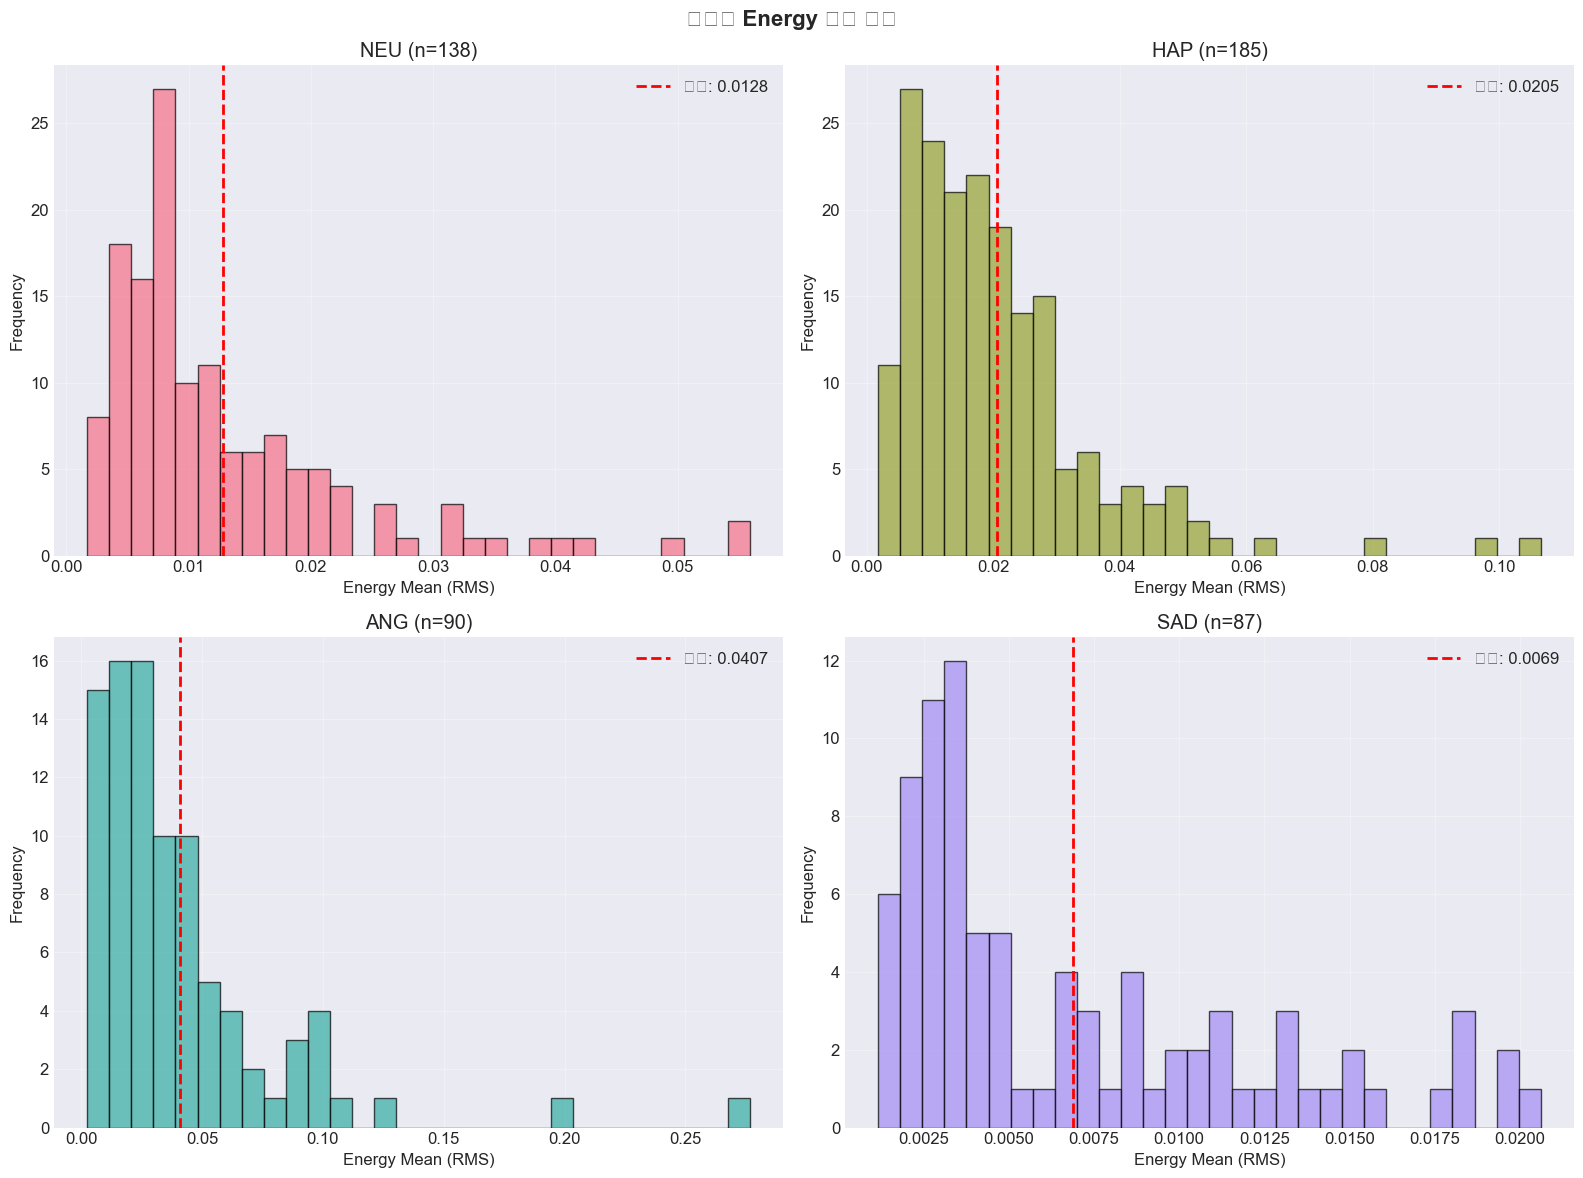

In [14]:

# 5.1 감정별 평균 Energy 분포
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('감정별 Energy 평균 분포', fontsize=16, fontweight='bold')

emotions = df_energy['emotion'].unique()
colors = sns.color_palette("husl", len(emotions))

for idx, emotion in enumerate(emotions):
    if idx >= 4: break # 최대 4개 감정만 표시
    ax = axes[idx // 2, idx % 2]
    emotion_data = df_energy[df_energy['emotion'] == emotion]['energy_mean']
    
    ax.hist(emotion_data, bins=30, alpha=0.7, color=colors[idx], edgecolor='black')
    ax.axvline(emotion_data.mean(), color='red', linestyle='--', linewidth=2, 
               label=f'평균: {emotion_data.mean():.4f}')
    ax.set_title(f'{emotion.upper()} (n={len(emotion_data)})')
    ax.set_xlabel('Energy Mean (RMS)')
    ax.set_ylabel('Frequency')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


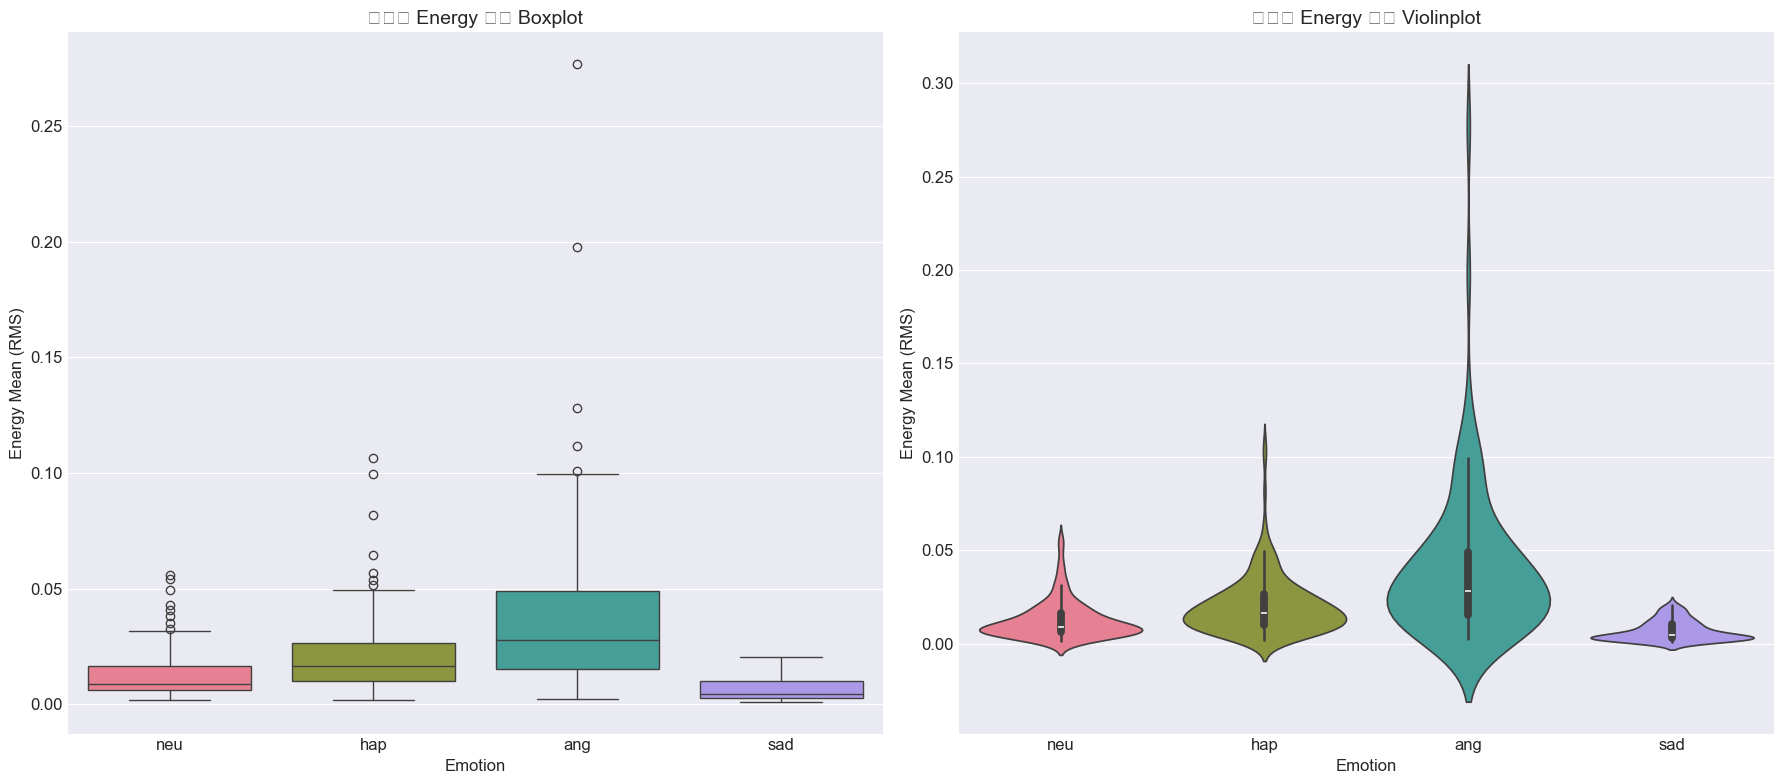

In [15]:

# 5.2 감정별 Energy 분포 비교 (Boxplot & Violinplot)
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Boxplot
sns.boxplot(x='emotion', y='energy_mean', data=df_energy, ax=axes[0], palette="husl")
axes[0].set_title('감정별 Energy 평균 Boxplot', fontsize=14)
axes[0].set_xlabel('Emotion')
axes[0].set_ylabel('Energy Mean (RMS)')

# Violinplot
sns.violinplot(x='emotion', y='energy_mean', data=df_energy, ax=axes[1], palette="husl")
axes[1].set_title('감정별 Energy 평균 Violinplot', fontsize=14)
axes[1].set_xlabel('Emotion')
axes[1].set_ylabel('Energy Mean (RMS)')

plt.tight_layout()
plt.show()


## 6. Energy Contour 시각화 (Waveform 제외)

Finding samples with duration ~3.0s for emotions: ['hap', 'neu', 'ang', 'sad']...
Found hap: duration=3.01s (Index: 93)
Found neu: duration=2.98s (Index: 223)
Found ang: duration=2.98s (Index: 2)
Found sad: duration=3.01s (Index: 96)

감정: HAP
오디오 재생:



Energy 통계:
  - 평균: 0.0190
  - 표준편차: 0.0108
  - 범위: 0.0523
  - 최소/최대: 0.0031 / 0.0554


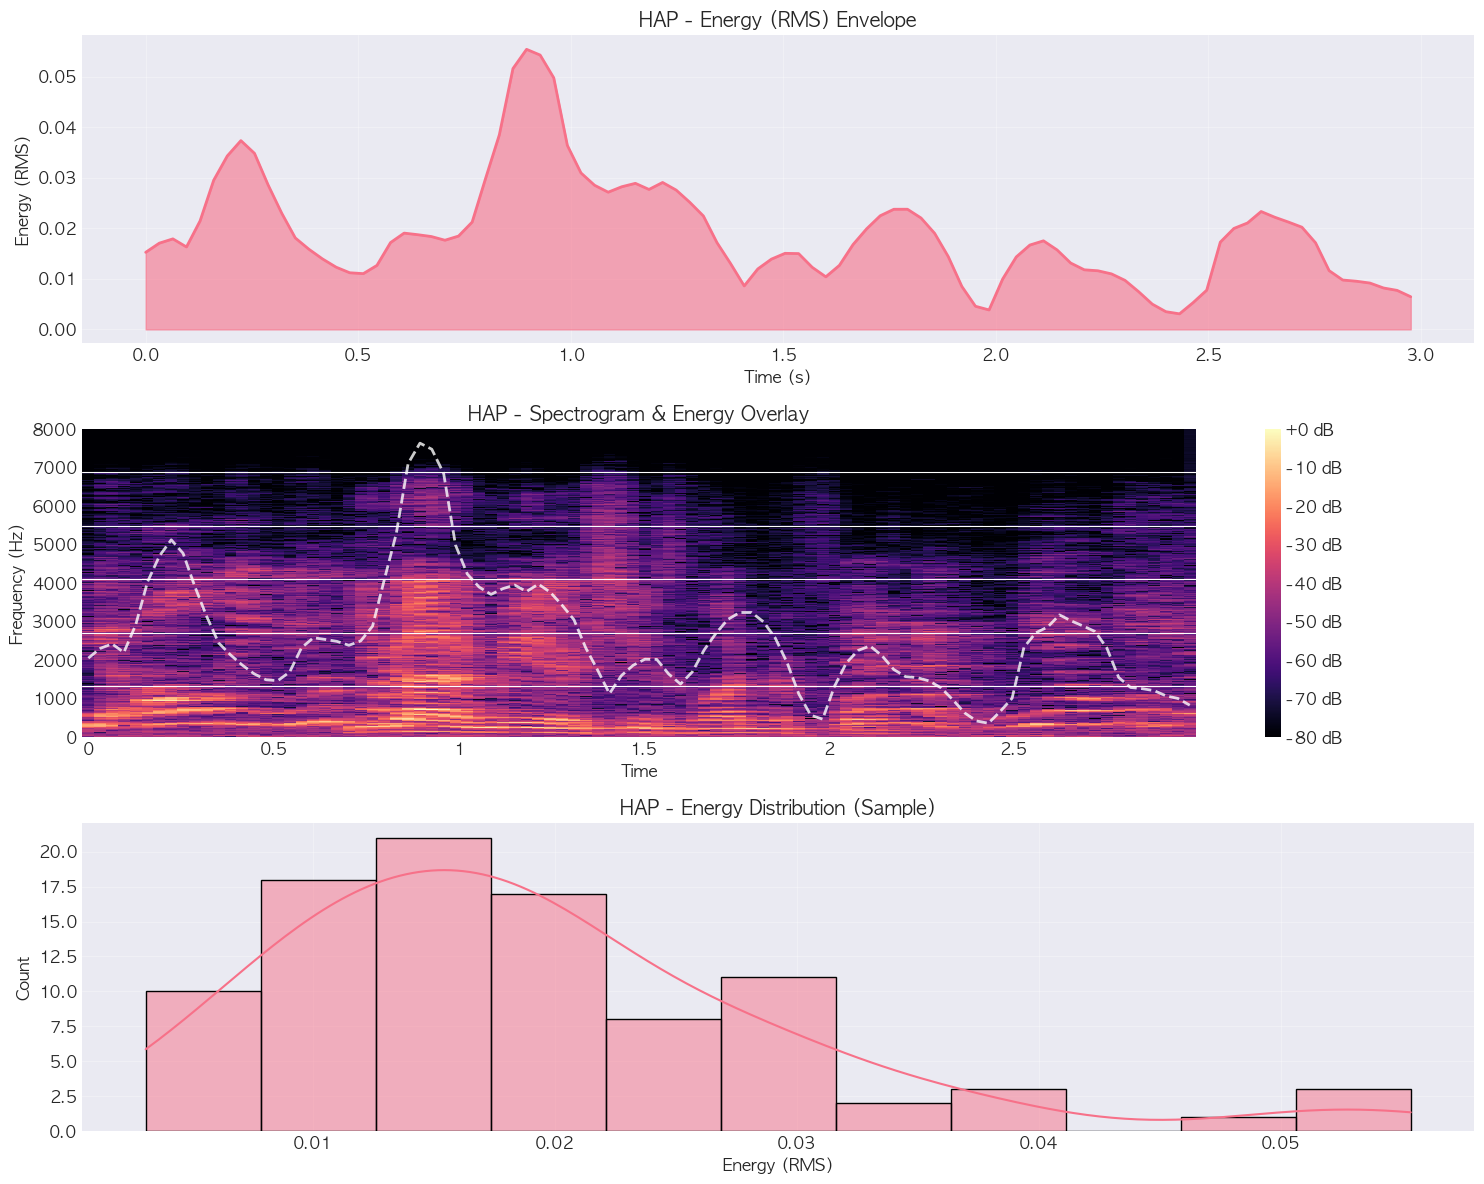


감정: NEU
오디오 재생:



Energy 통계:
  - 평균: 0.0133
  - 표준편차: 0.0083
  - 범위: 0.0324
  - 최소/최대: 0.0018 / 0.0342


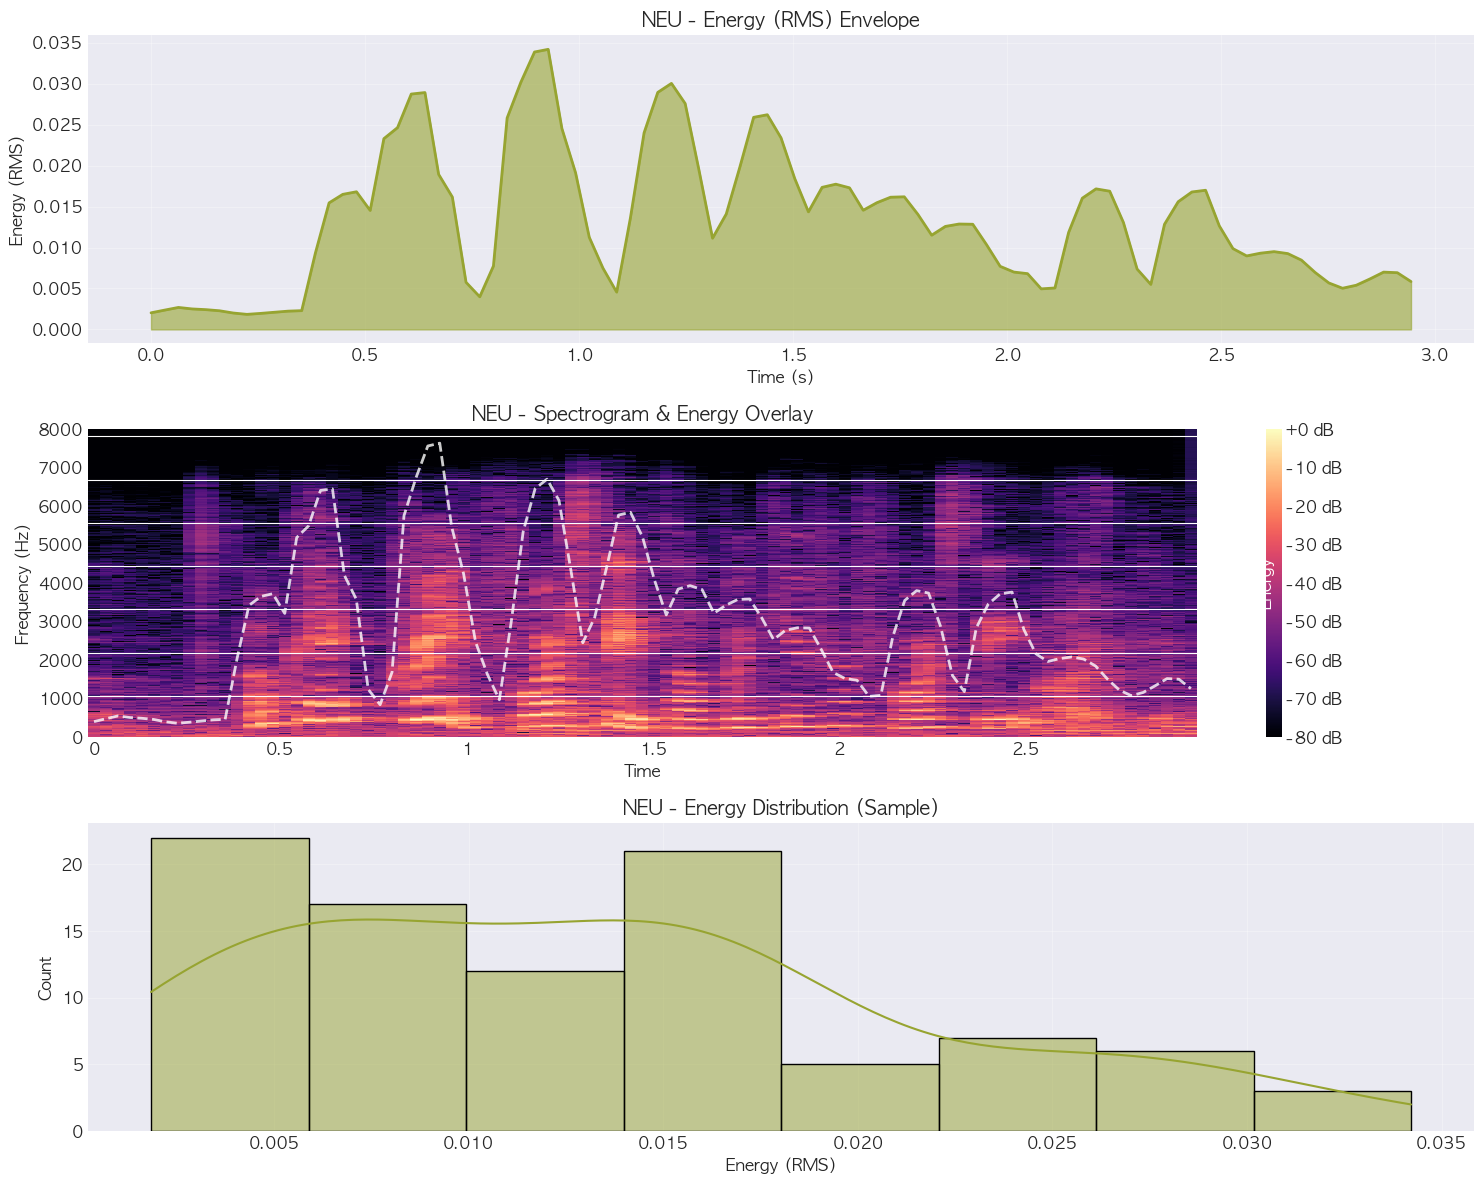


감정: ANG
오디오 재생:



Energy 통계:
  - 평균: 0.0259
  - 표준편차: 0.0325
  - 범위: 0.1375
  - 최소/최대: 0.0009 / 0.1383


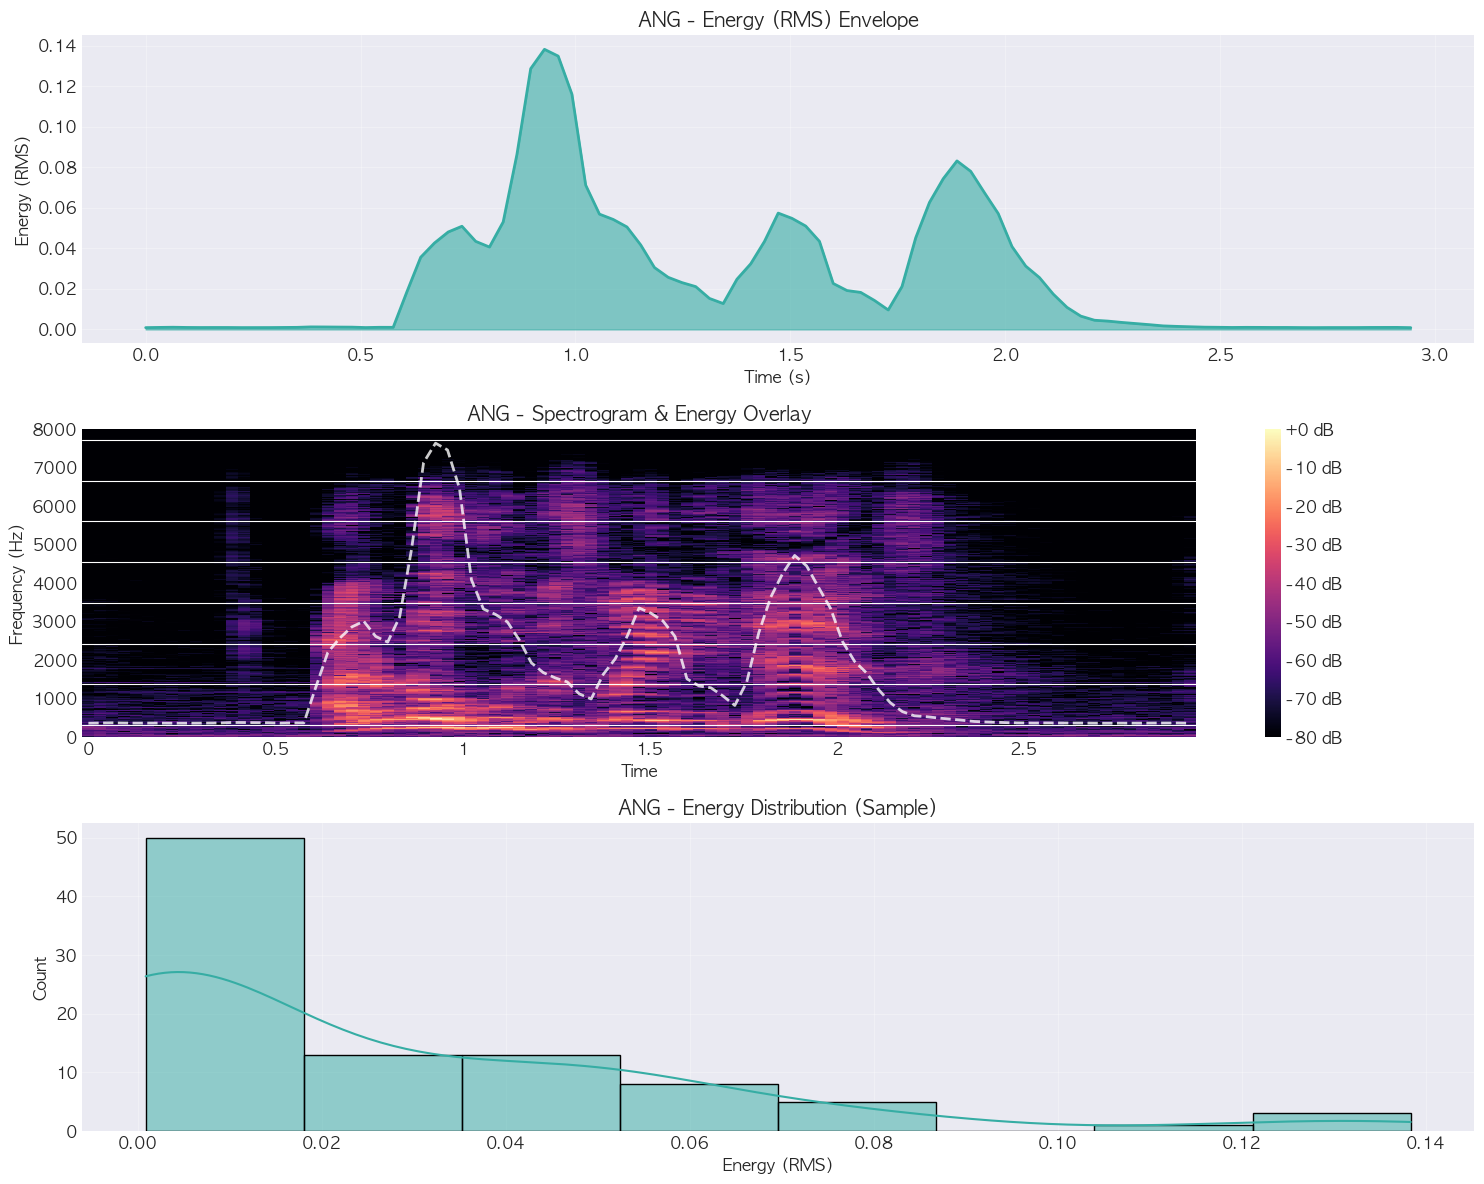


감정: SAD
오디오 재생:



Energy 통계:
  - 평균: 0.0087
  - 표준편차: 0.0084
  - 범위: 0.0351
  - 최소/최대: 0.0028 / 0.0380


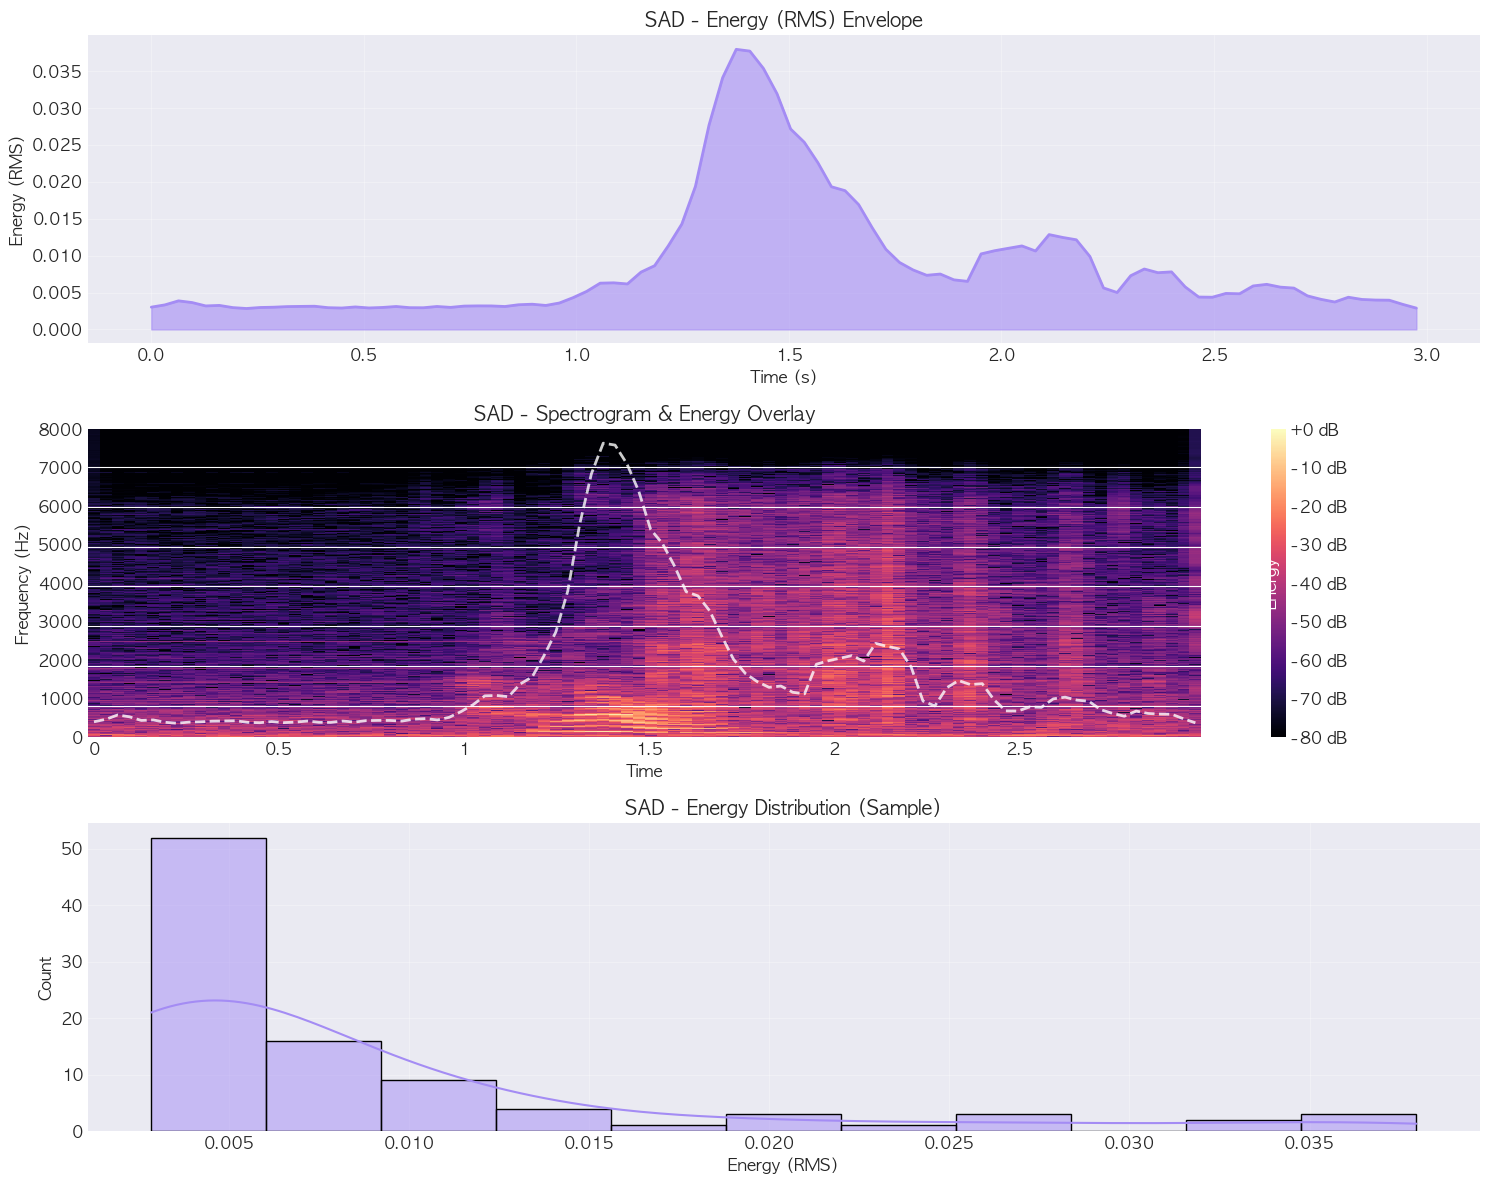

In [18]:

# IPython display를 사용하여 오디오 재생 및 스펙트로그램 시각화
from IPython.display import Audio as IPAudio
import librosa.display
import soundfile as sf
import io

# Target emotions and duration
target_emotions = ['hap', 'neu', 'ang', 'sad']
target_duration = 3.0
tolerance = 0.2  # +/- 0.2 seconds
hop_length = 512

print(f"Finding samples with duration ~{target_duration}s for emotions: {target_emotions}...")

selected_samples = {}
colors = sns.color_palette("husl", len(target_emotions))

# Find best matching samples
for emotion in target_emotions:
    best_sample = None
    min_diff = float('inf')
    
    # energy_data에서 검색
    for item in energy_data:
        # 감정 매핑 확인 (hap에 exc 포함 여부 등)
        # item['emotion']은 문자열 (ang, sad, hap, neu)
        if item['emotion'] != emotion:
            continue
            
        # Calculate duration
        # values length * hop_length / sr
        values = item['energy_values']
        duration = len(values) * hop_length / SAMPLE_RATE
        
        diff = abs(duration - target_duration)
        
        if diff < tolerance and diff < min_diff:
            min_diff = diff
            best_sample = item
            
    if best_sample:
        selected_samples[emotion] = best_sample
        duration = len(best_sample['energy_values']) * hop_length / SAMPLE_RATE
        print(f"Found {emotion}: duration={duration:.2f}s (Index: {best_sample['sample_idx']})")
    else:
        print(f"Warning: Could not find suitable sample for {emotion} within tolerance.")

# Visualization Loop
for i, emotion in enumerate(target_emotions):
    if emotion not in selected_samples:
        continue
        
    emotion_sample = selected_samples[emotion]
    sample_idx = emotion_sample['sample_idx']
    
    print(f"\n{'='*60}")
    print(f"감정: {emotion.upper()}")
    print(f"{'='*60}")
    
    # ⚠️ 수정: ds 대신 dataset_raw 사용
    sample = dataset_raw[sample_idx]
    
    # ⚠️ 수정: 오디오 디코딩 직접 수행
    audio_bytes = sample['audio']['bytes']
    audio_array, sr = sf.read(io.BytesIO(audio_bytes))
    
    # 오디오 재생
    print("오디오 재생:")
    display(IPAudio(audio_array, rate=SAMPLE_RATE))
    
    # 시각화
    fig, axes = plt.subplots(3, 1, figsize=(15, 12))
    
    # Values for plotting
    values = emotion_sample['energy_values']
    frames = range(len(values))
    t = librosa.frames_to_time(frames, sr=SAMPLE_RATE, hop_length=hop_length)
    color = colors[i]
    
    
    # 1. Energy Envelope (Filled)
    axes[0].fill_between(t, values, alpha=0.6, color=color)
    axes[0].plot(t, values, color=color, linewidth=2)
    axes[0].set_title(f'{emotion.upper()} - Energy (RMS) Envelope', fontsize=14, fontweight='bold')
    axes[0].set_ylabel('Energy (RMS)')
    axes[0].set_xlabel('Time (s)')
    axes[0].grid(True, alpha=0.3)
    
    # 2. Spectrogram with Energy Overlay
    D = librosa.amplitude_to_db(np.abs(librosa.stft(audio_array)), ref=np.max)
    img = librosa.display.specshow(D, sr=SAMPLE_RATE, x_axis='time', y_axis='hz', ax=axes[1])
    axes[1].set_title(f'{emotion.upper()} - Spectrogram & Energy Overlay', fontsize=14, fontweight='bold')
    axes[1].set_ylabel('Frequency (Hz)')
    fig.colorbar(img, ax=axes[1], format='%+2.0f dB')
    
    # Overlay Energy
    ax2 = axes[1].twinx()
    ax2.plot(t, values, color='white', linewidth=2, linestyle='--', alpha=0.8, label='Energy')
    ax2.set_ylabel('Energy', color='white')
    ax2.tick_params(axis='y', colors='white')
    
    # 3. Energy Histogram
    sns.histplot(values, kde=True, ax=axes[2], color=color)
    axes[2].set_title(f'{emotion.upper()} - Energy Distribution (Sample)', fontsize=14, fontweight='bold')
    axes[2].set_xlabel('Energy (RMS)')
    axes[2].set_ylabel('Count')
    axes[2].grid(True, alpha=0.3)
    
    # Stats
    print(f"\nEnergy 통계:")
    print(f"  - 평균: {emotion_sample['energy_mean']:.4f}")
    print(f"  - 표준편차: {emotion_sample['energy_std']:.4f}")
    print(f"  - 범위: {emotion_sample['energy_range']:.4f}")
    print(f"  - 최소/최대: {emotion_sample['energy_min']:.4f} / {emotion_sample['energy_max']:.4f}")
    
    plt.tight_layout()
    plt.show()
    

## 7. 통계적 유의성 검정 (ANOVA)

In [19]:

from scipy import stats

print("감정별 Energy 평균의 차이가 통계적으로 유의미한지 검정합니다.")

groups = []
for emotion in emotions:
    groups.append(df_energy[df_energy['emotion'] == emotion]['energy_mean'])

f_val, p_val = stats.f_oneway(*groups)

print(f"\nOne-way ANOVA 결과:")
print(f"F-statistic: {f_val:.4f}")
print(f"P-value: {p_val:.4e}")

if p_val < 0.05:
    print("\n결과: 감정 간에 Energy 평균의 차이가 통계적으로 유의미합니다. (p < 0.05)")
else:
    print("\n결과: 감정 간에 Energy 평균의 차이가 통계적으로 유의미하지 않습니다. (p >= 0.05)")


감정별 Energy 평균의 차이가 통계적으로 유의미한지 검정합니다.

One-way ANOVA 결과:
F-statistic: 47.0267
P-value: 9.2332e-27

결과: 감정 간에 Energy 평균의 차이가 통계적으로 유의미합니다. (p < 0.05)
